<a href="https://colab.research.google.com/github/Chandini-M555/Data_Science_Task/blob/main/Loan_Approval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loan Approval Prediction

In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
from sklearn.preprocessing import StandardScaler

In [124]:
#Load the data
df=pd.read_csv("/content/loan_data.csv")
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


# EDA

In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [126]:
#Handling outliers
#df=df[df["person_age"]<=100]


In [127]:
df["person_home_ownership"].unique()

array(['RENT', 'OWN', 'MORTGAGE', 'OTHER'], dtype=object)

In [128]:
df["loan_intent"].unique()

array(['PERSONAL', 'EDUCATION', 'MEDICAL', 'VENTURE', 'HOMEIMPROVEMENT',
       'DEBTCONSOLIDATION'], dtype=object)

<Axes: xlabel='loan_status', ylabel='Count'>

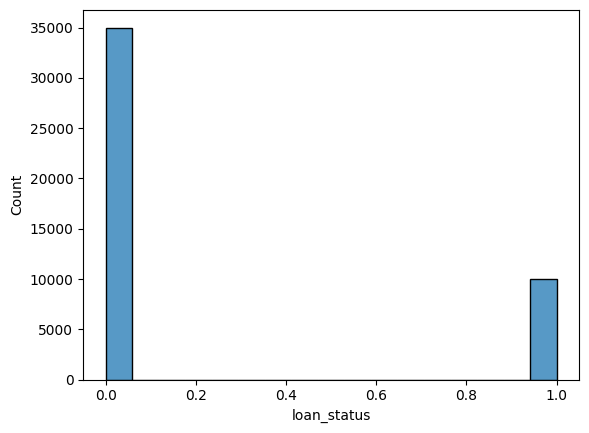

In [129]:
sns.histplot(x="loan_status",data=df)

<Axes: xlabel='person_education', ylabel='count'>

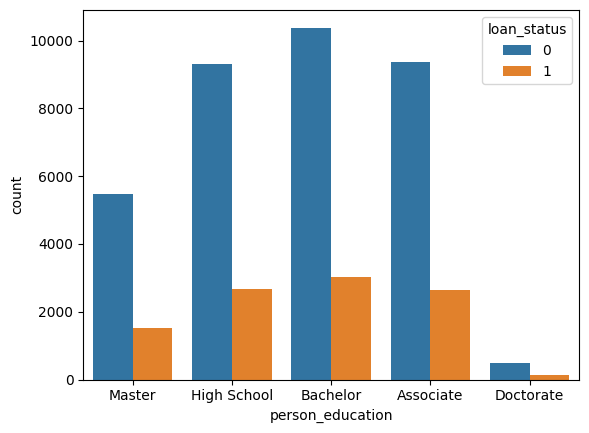

In [130]:
sns.countplot(x="person_education",data=df,hue="loan_status")

<Axes: xlabel='person_age', ylabel='Count'>

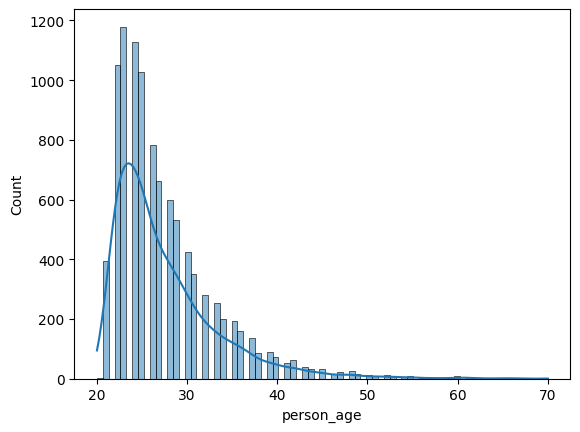

In [131]:
sns.histplot(x="person_age",data=df[df["loan_status"]==1],kde=True)

In [132]:
df.groupby("loan_status")["person_income"].mean()

,person_income
loan_status,
0,86157.040743
1,59886.096900


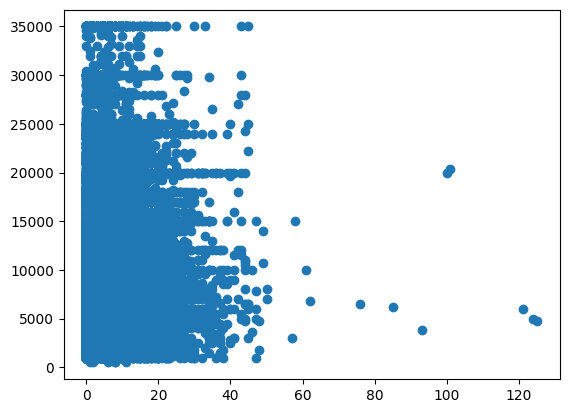

In [133]:
plt.scatter(df["person_emp_exp"],df["loan_amnt"])

<Axes: xlabel='credit_score', ylabel='Count'>

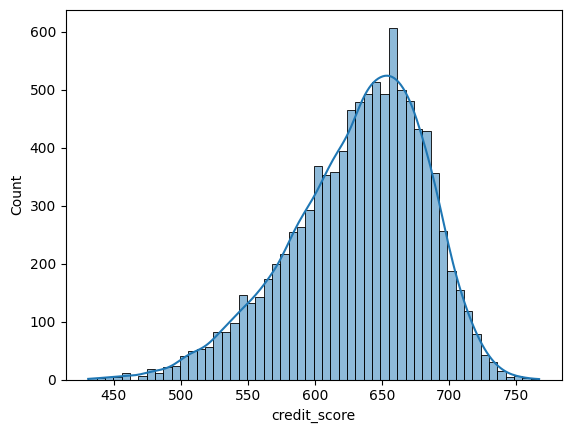

In [134]:
sns.histplot(x="credit_score",data=df[df["loan_status"]==1],kde=True)

In [135]:
nums_col=[col for col in df.columns if df[col].dtype!=object]
df[nums_col]

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
0,22.0,71948.0,0,35000.0,16.02,0.49,3.0,561,1
1,21.0,12282.0,0,1000.0,11.14,0.08,2.0,504,0
2,25.0,12438.0,3,5500.0,12.87,0.44,3.0,635,1
3,23.0,79753.0,0,35000.0,15.23,0.44,2.0,675,1
4,24.0,66135.0,1,35000.0,14.27,0.53,4.0,586,1
...,...,...,...,...,...,...,...,...,...
44995,27.0,47971.0,6,15000.0,15.66,0.31,3.0,645,1
44996,37.0,65800.0,17,9000.0,14.07,0.14,11.0,621,1
44997,33.0,56942.0,7,2771.0,10.02,0.05,10.0,668,1
44998,29.0,33164.0,4,12000.0,13.23,0.36,6.0,604,1


In [136]:
df[nums_col].corr

<bound method DataFrame.corr of        person_age  person_income  person_emp_exp  loan_amnt  loan_int_rate  \
0            22.0        71948.0               0    35000.0          16.02   
1            21.0        12282.0               0     1000.0          11.14   
2            25.0        12438.0               3     5500.0          12.87   
3            23.0        79753.0               0    35000.0          15.23   
4            24.0        66135.0               1    35000.0          14.27   
...           ...            ...             ...        ...            ...   
44995        27.0        47971.0               6    15000.0          15.66   
44996        37.0        65800.0              17     9000.0          14.07   
44997        33.0        56942.0               7     2771.0          10.02   
44998        29.0        33164.0               4    12000.0          13.23   
44999        24.0        51609.0               1     6665.0          17.05   

       loan_percent_income  cb_person_cred_hist_length  credit_score  \
0                     0.49                         3.0           561   
1                     0.08                         2.0           504   
2                     0.44                         3.0           635   
3                     0.44                         2.0           675   
4                     0.53                         4.0           586   
...                    ...                         ...           ...   
44995                 0.31                         3.0           645   
44996                 0.14                        11.0           621   
44997                 0.05                        10.0           668   
44998                 0.36                         6.0           604   
44999                 0.13                         3.0           628   

       loan_status  
0                1  
1                0  
2                1  
3                1  
4                1  
...            ...  
44995            1  
44996            1  
44997            1  
44998            1  
44999            1  

[45000 rows x 9 columns]>

<Axes: >

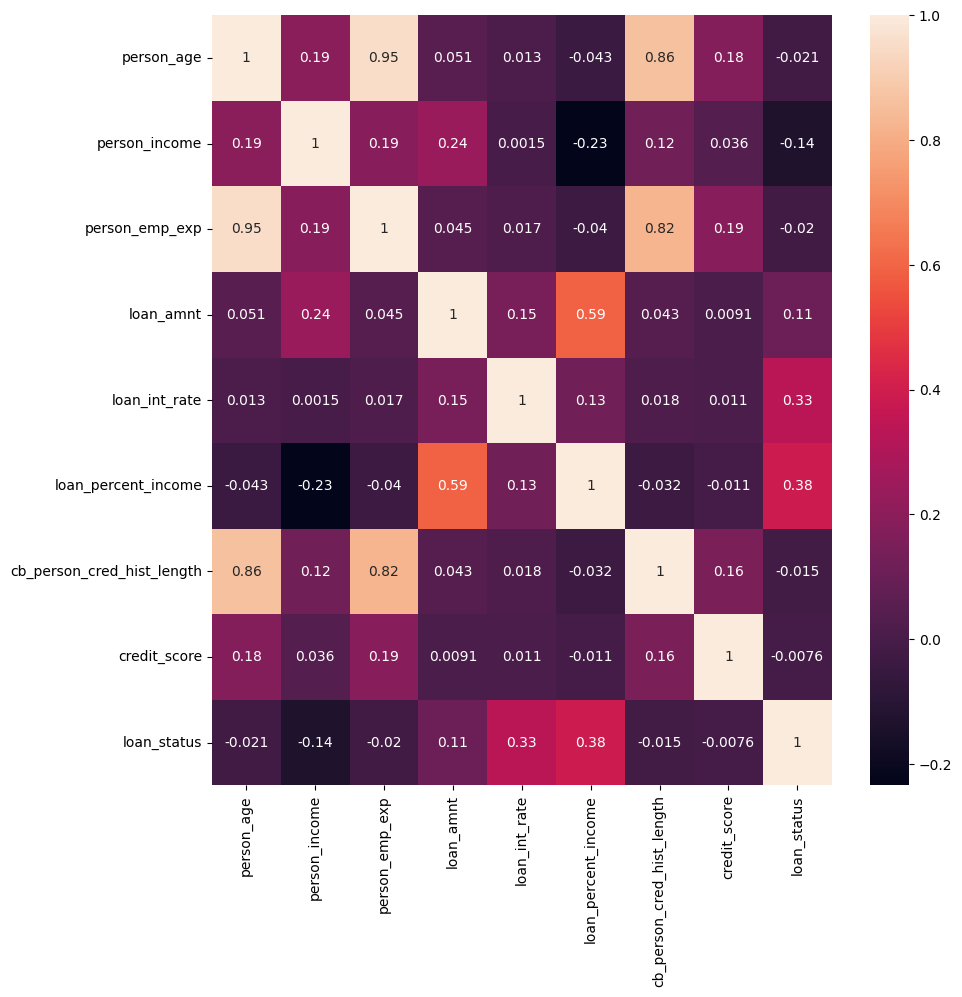

In [137]:
plt.figure(figsize=(10,10))
sns.heatmap(df[nums_col].corr(),annot=True)

# Model Training

In [138]:
#Encoding
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in df.columns:
  if df[col].dtype==object:
    df[col]=le.fit_transform(df[col])

In [139]:
#divide data into input and output
X=df.drop("loan_status",axis=1)
Y=df.loan_status

In [140]:
#splitting the data for training and testing
Xtrain,Xtest,Ytrain,Ytest=train_test_split(X,Y,test_size=0.3,random_state=42)

In [149]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
Xtrain=scaler.fit_transform(Xtrain)
Xtest=scaler.transform(Xtest)

In [142]:
model=SVC(kernel="rbf")
model.fit(Xtrain,Ytrain)

SVC()

# Model Evaluation and Tuning

In [143]:
ypred=model.predict(Xtest)
ypred

array([0, 0, 1, ..., 0, 0, 0])

In [144]:
confusion_matrix(Ytest,ypred)

array([[10007,   486],
       [  772,  2235]])

In [145]:
print(classification_report(Ytest,ypred))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94     10493
           1       0.82      0.74      0.78      3007

    accuracy                           0.91     13500
   macro avg       0.87      0.85      0.86     13500
weighted avg       0.90      0.91      0.91     13500



In [146]:
print("testing efficiency: ",model.score(Xtest,Ytest))
print("training efficiency: ",model.score(Xtrain,Ytrain))

testing efficiency:  0.9068148148148149
training efficiency:  0.9133650793650794


In [150]:
#new input prediction
new_data=df.iloc[0:1,:-1]
new_data=scaler.transform(new_data)
pred=model.predict(new_data)[0]
if pred==0:
  print("Loan not Approved")
else:
  print("Loan Approved")

Loan not Approved


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
